# **Compound Hot and Dry Periods Analysis**

**Study Period:** 1910- 2025

**Dry-Spell Definitions:**
 - Rolling percentile
 - Consecutive dry days

**Compound Definition:**
 - A day is a compound day if it is a heatwave day and it falls within an active dry spell under a given dry definition

Computing spatially averaged daily Tmax / Tmin / precip...
Tmax series: 1910-01-01 to 2025-12-31 (42369 days)
Tmin series: 1910-01-01 to 2025-12-31 (42369 days)
Precip series: 1900-01-01 to 2025-12-31 (46021 days)
df rows: 42369
season_df rows (Nov-Mar): 17545
heat_any days: 2115
dry_spi days: 4573
dry_consec days: 4790
compound_spi days: 354
compound_consec days: 290
Compound (SPI-style dry) annual aspects (tail):
             CDF  CEN  CED
season_year               
2020           0    0    0
2021           0    0    0
2022           0    0    0
2023           0    0    0
2024           6    1    6

Compound (consecutive dry days) annual aspects (tail):
             CDF  CEN  CED
season_year               
2020           0    0    0
2021           8    4    3
2022           0    0    0
2023           4    1    4
2024           6    1    6

SPI-style dry spell: lift = 1.60  (P(dry)=0.093, P(heat)=0.045, P(both)=0.0067, n=17545 season-days)
  lift > 1 => dry and heat co-occur more than

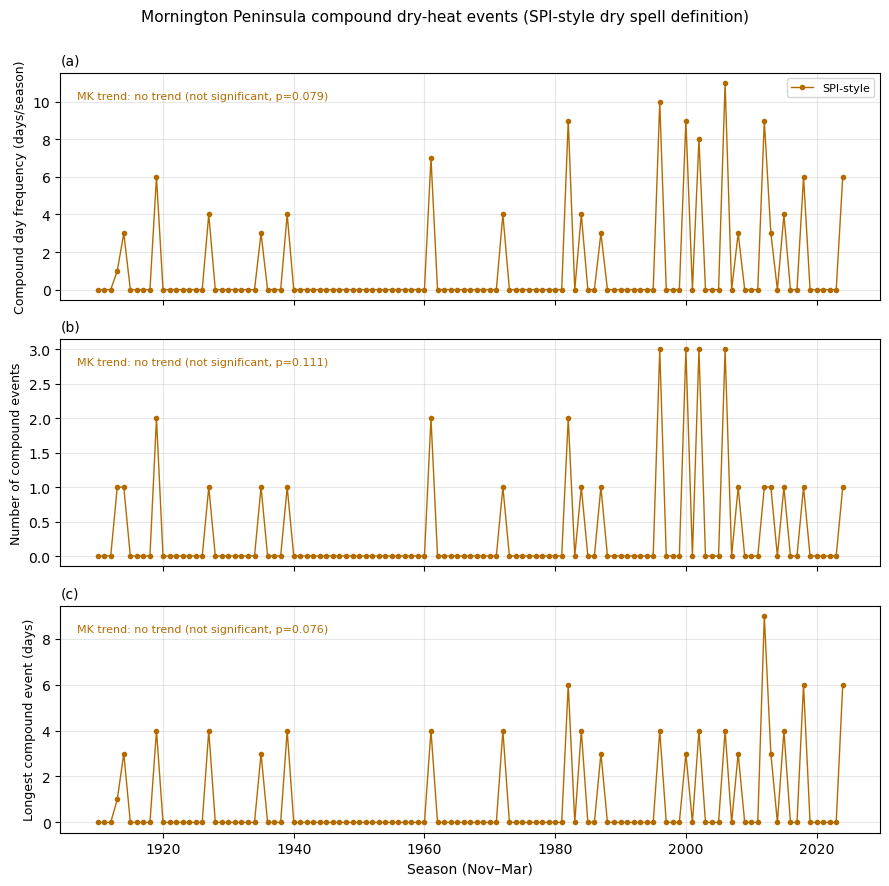

Saved figure to /home/563/ft3359/RA-MorningtonPeninsula/Figures/mornington_compound_dry_heat_spi.png


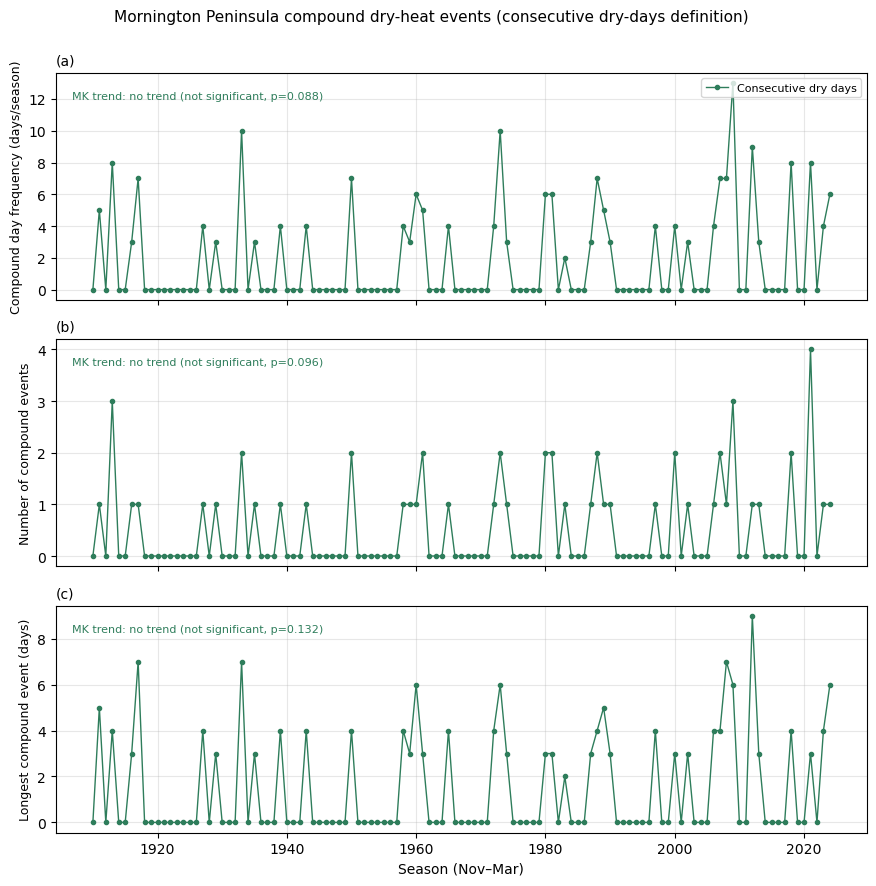

Saved figure to /home/563/ft3359/RA-MorningtonPeninsula/Figures/mornington_compound_dry_heat_consec.png


In [8]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pymannkendall as mk

# Configuration

# Mornington Peninsula Bounding Box
MIN_LAT, MAX_LAT = -38.50, -38.05
MIN_LON, MAX_LON = 144.68, 145.35

CLIM_START, CLIM_END = 1961, 1990

DOY_WINDOW = 15
PCTL_HOT = 90
PCTL_DRY = 10
MIN_HW_RUN = 3

DRY_ACCUM_WINDOW = 90
DRY_DAY_THRESHOLD = 1.0
MIN_DRY_RUN = 15

# Austral summer season
SEASON_MONTHS = [11, 12, 1, 2, 3]
SEASON_START_MONTH = 11

OUT_DIR = '/home/563/ft3359/RA-MorningtonPeninsula/Figures'
os.makedirs(OUT_DIR, exist_ok=True)


CACHE_DIR = '/scratch/ob22/ft3359/mornington_cache'


# Load cached tmax / tmin / precip 

tmax_grid = xr.open_dataarray(f'{CACHE_DIR}/tmax_grid_masked.nc').load()
tmin_grid = xr.open_dataarray(f'{CACHE_DIR}/tmin_grid_masked.nc').load()
precip_grid = xr.open_dataarray(f'{CACHE_DIR}/precip_gird_masked.nc').load()

print("Computing spatially averaged daily Tmax / Tmin / precip...")
TX = tmax_grid.mean(dim=['lat', 'lon'], skipna=True).to_series()
TN = tmin_grid.mean(dim=['lat', 'lon'], skipna=True).to_series()
P = precip_grid.mean(dim=['lat', 'lon'], skipna=True).to_series()

for s in (TX, TN, P):
    s.index = pd.to_datetime(s.index).normalize()
TX, TN, P = (s.sort_index() for s in (TX, TN, P))
TX = TX[~TX.index.duplicated()]
TN = TN[~TN.index.duplicated()]
P = P[~P.index.duplicated()]

print(f"Tmax series: {TX.index.min().date()} to {TX.index.max().date()} ({len(TX)} days)")
print(f"Tmin series: {TN.index.min().date()} to {TN.index.max().date()} ({len(TN)} days)")
print(f"Precip series: {P.index.min().date()} to {P.index.max().date()} ({len(P)} days)")


# Calendar-day Percentile Climatology

def build_doy(index):
    doy = index.dayofyear
    shift = (index.is_leap_year) & (doy > 59)
    return np.where(shift, doy - 1, doy)


def calendar_day_percentile(series, clim_start, clim_end, pctl, window):
    avail_start_year = series.index.min().year
    if clim_start < avail_start_year:
        clim_start = avail_start_year
        clim_end = clim_start + 29
        print(f"Reference period adjusted to {clim_start}-{clim_end} "
              f"(record doesn't reach {CLIM_START})")

    mask = (series.index.year >= clim_start) & (series.index.year <= clim_end)
    ref = series[mask].dropna()
    ref = ref[~((ref.index.month == 2) & (ref.index.day == 29))]
    ref_doy = build_doy(ref.index)
    ref_df = pd.DataFrame({'doy': ref_doy, 'val': ref.values})

    thresholds = {}
    for d in range(1, 366):
        window_doys = [((x - 1) % 365) + 1 for x in range(d - window, d + window + 1)]
        vals = ref_df.loc[ref_df['doy'].isin(window_doys), 'val']
        thresholds[d] = np.nanpercentile(vals, pctl) if len(vals) > 0 else np.nan

    full_doy = build_doy(series.index)
    return pd.Series(full_doy, index=series.index).map(thresholds)


TX90 = calendar_day_percentile(TX, CLIM_START, CLIM_END, PCTL_HOT, DOY_WINDOW)
TN90 = calendar_day_percentile(TN, CLIM_START, CLIM_END, PCTL_HOT, DOY_WINDOW)

# SPI-style: build the rolling accumulated total first, THEN take its calendar-day 10th percentile from the reference period
P_roll = P.rolling(DRY_ACCUM_WINDOW, min_periods=DRY_ACCUM_WINDOW).sum()
P10_roll = calendar_day_percentile(P_roll, CLIM_START, CLIM_END, PCTL_DRY, DOY_WINDOW)


# Flag heatwave days

def flag_run(exceed_bool, min_run):
    exceed = exceed_bool.astype(int)
    run_id = (exceed != exceed.shift()).cumsum()
    run_length = exceed.groupby(run_id).transform('size') * exceed
    is_day = (exceed == 1) & (run_length >= min_run)
    event_id = np.where(is_day, run_id, np.nan)
    return is_day, event_id


tx_is_hw, tx_event_id = flag_run(TX > TX90, MIN_HW_RUN)
tn_is_hw, tn_event_id = flag_run(TN > TN90, MIN_HW_RUN)
heat_any = tx_is_hw | tn_is_hw


# Flag dry-spell days under both definitions

# Definition 1: SPI-style
dry_spi = (P_roll < P10_roll)

# Definition 2: consecutive dry days
dry_consec, dry_consec_event_id = flag_run(P < DRY_DAY_THRESHOLD, MIN_DRY_RUN)


# Compound days: heatwave day concurrent with an active dry spell, under each dry definition

compound_spi = heat_any & dry_spi
compound_consec = heat_any & dry_consec

df = pd.DataFrame({
    'TX': TX, 'TN': TN, 'P': P,
    'heat_any': heat_any,
    'dry_spi': dry_spi, 'dry_consec': dry_consec,
    'compound_spi': compound_spi, 'compound_consec': compound_consec,
}).dropna(subset=['TX', 'TN'])


# Restrict to Nov-Mar season

season_df = df[df.index.month.isin(SEASON_MONTHS)].copy()
season_df['season_year'] = np.where(
    season_df.index.month >= SEASON_START_MONTH,
    season_df.index.year,
    season_df.index.year - 1
)

print(f"df rows: {len(df)}")
print(f"season_df rows (Nov-Mar): {len(season_df)}")
print(f"heat_any days: {int(df['heat_any'].sum())}")
print(f"dry_spi days: {int(df['dry_spi'].sum())}")
print(f"dry_consec days: {int(df['dry_consec'].sum())}")
print(f"compound_spi days: {int(df['compound_spi'].sum())}")
print(f"compound_consec days: {int(df['compound_consec'].sum())}")


# Annual compound aspects: CDF, CEN, CED -- for each dry def

def compute_compound_aspects(season_df, compound_col):
    columns = ['season_year', 'CDF', 'CEN', 'CED']
    records = []
    for yr, grp in season_df.groupby('season_year'):
        comp = grp[compound_col].astype(int)
        run_id = (comp != comp.shift()).cumsum()
        run_length = comp.groupby(run_id).transform('size') * comp
        is_event_day = comp == 1
        n_events = run_id[is_event_day].nunique() if is_event_day.any() else 0
        ced = run_length[is_event_day].groupby(run_id[is_event_day]).max().max() \
            if is_event_day.any() else 0
        records.append({'season_year': yr, 'CDF': int(comp.sum()),
                         'CEN': n_events, 'CED': ced if is_event_day.any() else 0})
    out = pd.DataFrame(records, columns=columns).set_index('season_year').sort_index()
    if len(out) > 2:
        out = out.loc[out.index[1:-1]]
    return out


spi_metrics = compute_compound_aspects(season_df, 'compound_spi')
consec_metrics = compute_compound_aspects(season_df, 'compound_consec')

if spi_metrics.empty or consec_metrics.empty:
    raise RuntimeError(
        "No seasons made it through to spi_metrics/consec_metrics. Check the "
        "diagnostic counts printed above -- most likely dry_spi/dry_consec "
        "came back all-False (thresholds not overlapping the loaded record) "
        "or season_df is empty."
    )

print("Compound (SPI-style dry) annual aspects (tail):")
print(spi_metrics.tail())
print("\nCompound (consecutive dry days) annual aspects (tail):")
print(consec_metrics.tail())


# Co-occurrence ratio

def lift(season_df, dry_col, heat_col='heat_any'):
    n = len(season_df)
    p_dry = season_df[dry_col].mean()
    p_heat = season_df[heat_col].mean()
    p_both = (season_df[dry_col] & season_df[heat_col]).mean()
    expected = p_dry * p_heat
    return (p_both / expected if expected > 0 else np.nan), p_dry, p_heat, p_both, n


for name, col in [('SPI-style dry spell', 'dry_spi'), ('Consecutive dry days', 'dry_consec')]:
    l, p_dry, p_heat, p_both, n = lift(season_df, col)
    print(f"\n{name}: lift = {l:.2f}  (P(dry)={p_dry:.3f}, P(heat)={p_heat:.3f}, "
          f"P(both)={p_both:.4f}, n={n} season-days)")
    print("  lift > 1 => dry and heat co-occur more than expected if independent")


# Trend statistics (Mann-Kendall / Sen's slope)

def trend_stats(series, min_n=8):
    s = series.dropna()
    if len(s) < min_n:
        return {'trend': 'insufficient data', 'p': np.nan, 'slope': np.nan, 'n': len(s)}
    result = mk.original_test(s.values)
    return {'trend': result.trend, 'p': result.p, 'slope': result.slope, 'n': len(s)}


def fmt_trend_label(stats):
    if np.isnan(stats['p']):
        return f"insufficient data (n={stats['n']})"
    sig = 'significant' if stats['p'] < 0.05 else 'not significant'
    p_str = "p<0.001" if stats['p'] < 0.001 else f"p={stats['p']:.3f}"
    return f"MK trend: {stats['trend']} ({sig}, {p_str})"


aspect_labels = {
    'CDF': 'Compound day frequency (days/season)',
    'CEN': 'Number of compound events',
    'CED': 'Longest compound event (days)',
}

trend_results = {'SPI-style': {}, 'Consecutive dry days': {}}
metrics_by_def = {'SPI-style': spi_metrics, 'Consecutive dry days': consec_metrics}
for col in aspect_labels:
    for defn, metrics in metrics_by_def.items():
        trend_results[defn][col] = trend_stats(metrics[col])
        print(f"{defn} {col}: {fmt_trend_label(trend_results[defn][col])}")


# Plots

panel_letters = ['(a)', '(b)', '(c)']

def make_compound_figure(metrics, defn_name, color, filename, title_suffix):
    fig, axes = plt.subplots(len(aspect_labels), 1, figsize=(9, 3 * len(aspect_labels)),
                              sharex=True)
    for ax, (col, label), letter in zip(axes, aspect_labels.items(), panel_letters):
        y = metrics[col]
        ax.plot(y.index, y.values, marker='o', ms=3, lw=1, color=color, label=defn_name)
        stats = trend_results[defn_name][col]
        ax.set_ylabel(label, fontsize=9)
        ax.set_title(letter, fontsize=10, loc='left')
        ax.text(0.02, 0.92, fmt_trend_label(stats), transform=ax.transAxes, fontsize=8,
                 va='top', color=color)
        ax.grid(alpha=0.3)
    axes[0].legend(loc='upper right', fontsize=8)
    axes[-1].set_xlabel('Season (Nov\u2013Mar)')
    fig.suptitle(f'Mornington Peninsula compound dry-heat events {title_suffix}\n', fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 1])
    fig.savefig(f'{OUT_DIR}/{filename}', dpi=200)
    plt.show()
    print(f"Saved figure to {OUT_DIR}/{filename}")


# Main figure: SPI-style
make_compound_figure(spi_metrics, 'SPI-style', '#B36B00',
                      'mornington_compound_dry_heat_spi.png',
                      '(SPI-style dry spell definition)')

# Supplementary figure: consecutive dry days
make_compound_figure(consec_metrics, 'Consecutive dry days', '#2E7D5B',
                      'mornington_compound_dry_heat_consec.png',
                     '(consecutive dry-days definition)')